## Using Genetic Algorithm's to find the optimal portfolio weightings

Recently, i have studied artificial intelligence at univeristy and i had come accross genetic algorithms and i am very intrigued in their applications in finance.

**My Goal** is to see if i can use genetic algrithms to find the most *optimal* portfolio of ETF's where it can be held for an extended period of time (an investment horizon of 10 years) and experience the highest return to volatility ratio. 

The plan is to have a chromosome of portfolio weights from 0 to 1 but the whole portfolio being equal to 1, meaning no shorting.|

Each bit in a chromosome will represent an ETF of a particular asset class, and the fitness function would be the Sharpe Ratio

![Sharpe Ratio](SharpeRatio.PNG)

*Formula taken from Investopedia see link below*

More about the sharpe ratio can be found at [Investopedia](https://www.investopedia.com/terms/s/sharperatio.asp)


With the Sharpe Ratio, for conveinience i will be removing the risk-free rate from the equation, this is should not impact the comparison of the assets.

In [1]:
#Packages Used
import pandas as pd
import yfinance as yf
from datetime import date
import random
import numpy as np
from dateutil.relativedelta import relativedelta
import matplotlib.pyplot as plt
import statistics
import pandas_datareader as data


In [2]:
df=pd.read_excel('ETF.xlsx')

These are the ETF's in Scope, so initially i will get the latest date out of all the inception date's and then get the daily prices for all the etf's in the file. This will allow future use of the algorithm if i want to add future ETF's


In [3]:
df

,Asset Class,Ticker,ETF Name,Inception Date
0,Real Estate,VAP.AX,Vanguard Australian Property Securities Index ...,2010-10-11
1,Cash,AAA.AX,BetaShares Australian High Interest Cash ETF,2012-04-02
2,Fixed Interest,VAF.AX,Vanguard Australian Fixed Interest Index,2012-10-29
3,International Equities,VGS.AX,Vanguard MSCI Index International Shares,2014-11-18
4,Equities,VAS.AX,Vanguard Australian Shares Index ETF,2009-05-04


In [4]:
start_date = str(max(df['Inception Date'].to_list()))[:10]
today = date.today()- relativedelta(years=1)
end_date =today.strftime("%Y-%m-%d")

tickers = df['Ticker'].to_list()

Next, i am going to get all the returns for a each ticker in the dataframe and add them to one main dataframe called base.

In [5]:
ticker_obj = yf.Ticker(tickers[0])
base= ticker_obj.history(start=start_date, end= end_date)
base=base['Close']

for ticker in tickers:
 #create initial yfinance object
    ticker_obj = yf.Ticker(ticker)
    
    #getting historical data, also adding dividends to close price for accurate returns- assuming
    # a reinvestment plan is taken for every asset
    hist= ticker_obj.history(start=start_date, end= end_date)
    hist[ticker]=hist['Close']+hist['Dividends']

    #getting returns
    hist = hist[ticker].pct_change(1)
    
    
    base=pd.merge(base, hist, left_index=True, right_index=True)

base=base.drop(columns=['Close'])
    


### Fitness Function

Takes in a list of portfolio weights (assumed to be in order of list, Tickers), the computes a sharpe ratio followed by an annualised sharpe ratio

This is a modified ratio, i do not take into account the risk free rate, my rational is that the market and conservative index i will be comparing this to will also have the risk-free rate within the returns of the stock.

In [6]:
def fitness_of_Portfolio(weights):

    temp_df=base

    for idx in range(len(weights)):
        #multiplying dataframe assets by stock weights
        temp_df.iloc[:,idx]=temp_df.iloc[:,idx]*weights[idx]
    
    #getting sum returns of portfolio
    temp_df['sum']= temp_df[base.columns].sum(axis=1)

    #sharpe ratio
    sharpe = temp_df['sum'].mean()/temp_df['sum'].std()

    #annualised sharpe ratio
    annualised_sharpe=(252**0.5)*sharpe

    return annualised_sharpe
    

### Function: Generate weights

Used for testing and to generate initial random weights for the population

In [7]:
def generate_weights(n_len):
    weights = [random.random() for x in range(n_len)]
    weights = weights/ np.sum(weights)
    
    return weights.tolist()

In [8]:
# tournament selection
def selection(pop, scores, k=3):
	# first random selection
	selection_ix = np.random.randint(len(pop))
	for ix in np.random.randint(0, len(pop), k-1):
		# check if better (e.g. perform a tournament)
		if scores[ix] < scores[selection_ix]:
			selection_ix = ix
	return pop[selection_ix]

In [9]:
def crossover(p1, p2, r_cross):
	# children are copies of parents by default
	c1, c2 = p1.copy(), p2.copy()
	# check for recombination
	if np.random.rand() < r_cross:
		# select crossover point that is not on the end of the string
		for idx in range(0,len(tickers),2):
			c1[idx]=p2[idx]
			c2[idx]=p2[idx]
		
	return [c1, c2]

In [10]:
# mutation operator
def mutation(chromo, mutation_rate):
	for i in range(len(chromo)):
		# check for a mutation
		if np.random.rand() < mutation_rate:
			# flip the bit
			chromo[i] = random.random()
	
	

### Function: Genetic Algorithm

Main function used to initialize function. Takes in number of desired iterations, population size, crossover rate and mutation rate.


In [11]:
def genetic_algorithm(n_iter, n_pop, r_cross, r_mut):
	# initial population of random bitstring
	pop =[generate_weights(len(tickers)) for x in range(n_pop)]
	# keep track of best solution
	best, best_eval = 0, fitness_of_Portfolio(pop[0])
	# enumerate generations
	for gen in range(n_iter):
		#print("****************************************************")
		#print("Starting generation: ", gen)

		# evaluate all candidates in the population
		scores = [fitness_of_Portfolio(c) for c in pop]
		# check for new best solution
		for i in range(n_pop):
			if scores[i] < best_eval:
				best, best_eval = pop[i], scores[i]
				
		

		# select parents
		selected = [selection(pop, scores) for _ in range(n_pop)]
		# create the next generation
		children = list()
		for i in range(0, n_pop, 2):
			# get selected parents in pairs
			p1, p2 = selected[i], selected[i+1]
			# crossover and mutation
			for c in crossover(p1, p2, r_cross):
				# mutation
				
				mutation(c, r_mut)
				
					
				# store for next generation

				c= c/np.sum(c)
				children.append(c)
		# replace population
		pop = children

		#print("Best Portfolio: ", best)
		#print("Best Fitness: ", best_eval)

		
	return [best, best_eval]

In [12]:
best_portfolio =genetic_algorithm( 1000, 100, 0.2,0.2)
print(best_portfolio)

[[0.23943167327550427, 0.20948049862512327, 0.272297336549814, 0.23370518411207625, 0.04508530743748222], 0.4073631689426122]


### Back-testing to verify GA actually works

In [13]:

#Re declaring dates
start_date = str(max(df['Inception Date'].to_list()))[:10]
today = date.today()
end_date =today.strftime("%Y-%m-%d")

In [14]:
#getting daily returns for best portfolio

ticker_obj = yf.Ticker(tickers[0])
base= ticker_obj.history(start=start_date, end= end_date)
base=base['Close']



for ticker,weight in zip(tickers, best_portfolio[0]):
    ticker_obj = yf.Ticker(ticker)
    hist= ticker_obj.history(start=start_date, end= end_date)
    hist['price']=hist['Close']+hist['Dividends']

    hist[ticker]=hist['price']*weight
    hist=hist[ticker]
    base=pd.merge(base, hist, left_index=True, right_index=True)
    

base=base.drop(columns=['Close'])
base['GA Portfolio']=base.sum(axis=1)
base=base['GA Portfolio']

### Benchmark: Conservative Index

In [15]:
ticker_banchmark= yf.Ticker('VDCO.AX')
con_benchmark= ticker_banchmark.history(start=start_date, end= end_date)
con_benchmark['Conservative Benchmark']=con_benchmark['Close']+con_benchmark['Dividends']

con_benchmark =con_benchmark['Conservative Benchmark']

### Benchmark: Australian Shares 

In [16]:
ticker_indx= yf.Ticker('VAS.AX')
market_indx_asx= ticker_indx.history(start=start_date, end= end_date)
market_indx_asx['Australian Shares Benchmark']=market_indx_asx['Close']+market_indx_asx['Dividends']

market_indx_asx=market_indx_asx['Australian Shares Benchmark']

In [17]:
final_df=pd.merge(market_indx_asx, con_benchmark, left_index=True, right_index=True)
final_df=pd.merge(final_df, base, left_index=True, right_index=True)


## Final Returns for all portfolios

In [18]:
final_df.head()

,Australian Shares Benchmark,Conservative Benchmark,GA Portfolio
Date,,,
2017-11-20 00:00:00+11:00,76.199997,50.000000,62.158302
2017-11-21 00:00:00+11:00,76.430000,50.079700,62.314216
2017-11-22 00:00:00+11:00,76.699997,50.144100,62.411404
2017-11-23 00:00:00+11:00,76.709999,50.220001,62.242796
2017-11-24 00:00:00+11:00,76.629997,50.220001,62.357496


In [19]:
#normalizing all returns
normalized = final_df/final_df.iloc[0,:]

In [20]:
normalized.head()

,Australian Shares Benchmark,Conservative Benchmark,GA Portfolio
Date,,,
2017-11-20 00:00:00+11:00,1.000000,1.000000,1.000000
2017-11-21 00:00:00+11:00,1.003018,1.001594,1.002508
2017-11-22 00:00:00+11:00,1.006562,1.002882,1.004072
2017-11-23 00:00:00+11:00,1.006693,1.004400,1.001359
2017-11-24 00:00:00+11:00,1.005643,1.004400,1.003205


### Plotting returns against two benchmarks

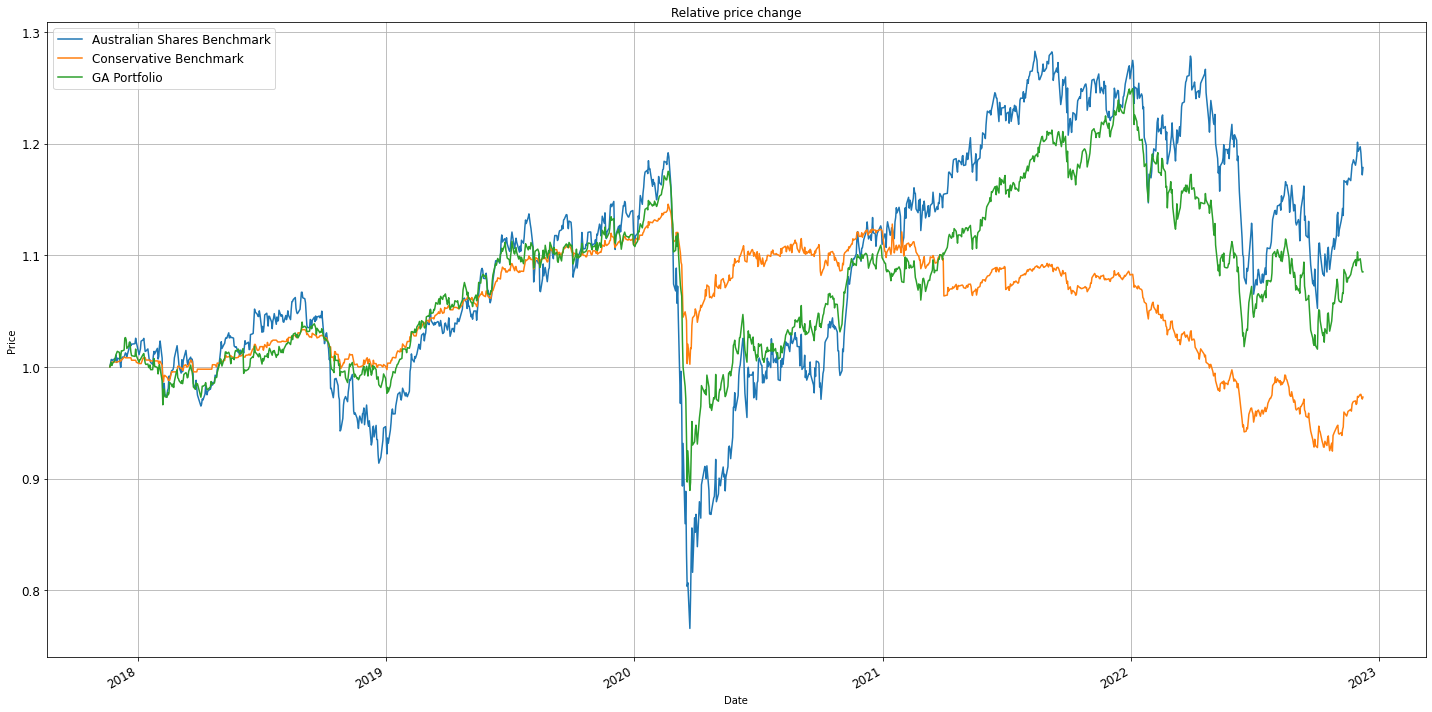

In [21]:
ax = normalized.plot(title='Normalized Comparison', fontsize=12, figsize=(20, 10))
ax.set_xlabel("Date")
ax.set_ylabel("Price")

plt.title('Relative price change')
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.style.use('bmh')
plt.grid(True)
plt.show()

### Forward testing

In [22]:
year_ago = date.today()- relativedelta(years=1)
today = date.today()
end_date =today.strftime("%Y-%m-%d")
start_date =year_ago.strftime("%Y-%m-%d")

In [23]:
ticker_obj = yf.Ticker(tickers[0])
base= ticker_obj.history(start=start_date, end= end_date)
base=base['Close']



for ticker,weight in zip(tickers, best_portfolio[0]):
    ticker_obj = yf.Ticker(ticker)
    hist= ticker_obj.history(start=start_date, end= end_date)
    hist['price']=hist['Close']+hist['Dividends']

    hist[ticker]=hist['price']*weight
    hist=hist[ticker]
    base=pd.merge(base, hist, left_index=True, right_index=True)
    

base=base.drop(columns=['Close'])
base['GA Portfolio']=base.sum(axis=1)
base=base['GA Portfolio']

In [24]:
ticker_banchmark= yf.Ticker('VDCO.AX')
con_benchmark= ticker_banchmark.history(start=start_date, end= end_date)
con_benchmark['Conservative Benchmark']=con_benchmark['Close']+con_benchmark['Dividends']

con_benchmark =con_benchmark['Conservative Benchmark']

In [25]:
ticker_indx= yf.Ticker('VAS.AX')
market_indx_asx= ticker_indx.history(start=start_date, end= end_date)
market_indx_asx['Australian Shares Benchmark']=market_indx_asx['Close']+market_indx_asx['Dividends']

market_indx_asx=market_indx_asx['Australian Shares Benchmark']

In [26]:
final_df=pd.merge(market_indx_asx, con_benchmark, left_index=True, right_index=True)
final_df=pd.merge(final_df, base, left_index=True, right_index=True)
normalized = final_df/final_df.iloc[0,:]


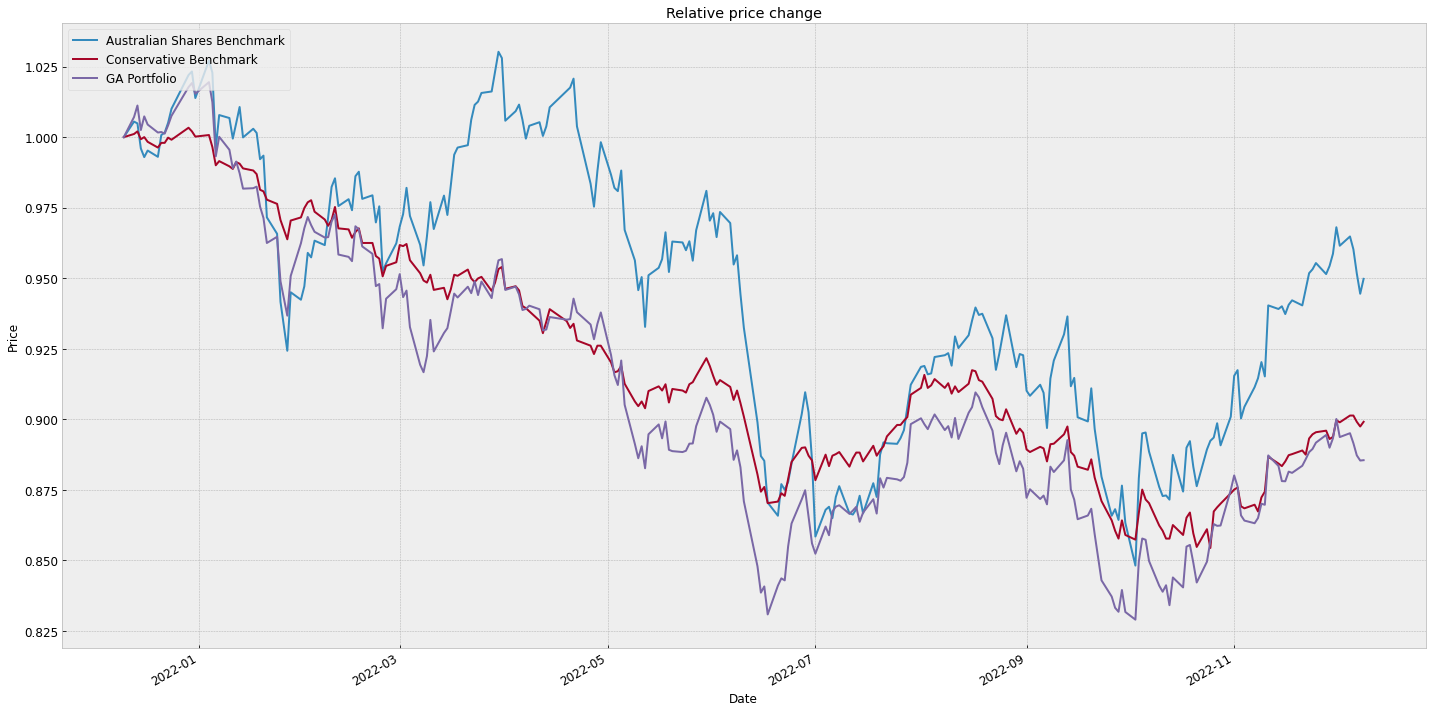

In [27]:
ax = normalized.plot(title='Normalized Comparison', fontsize=12, figsize=(20, 10))
ax.set_xlabel("Date")
ax.set_ylabel("Price")

plt.title('Relative price change')
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.style.use('bmh')
plt.grid(True)
plt.show()

In [28]:
return_final=final_df.pct_change(1)
return_final= return_final.sum()

In [29]:
final_df.std()

Australian Shares Benchmark    4.427067
Conservative Benchmark         2.226797
GA Portfolio                   3.635096
dtype: float64

In [30]:
return_final

Australian Shares Benchmark   -0.037848
Conservative Benchmark        -0.103760
GA Portfolio                  -0.114084
dtype: float64

In [31]:
print("Australian Shares Benchmark Fitness: ",return_final['Australian Shares Benchmark']/final_df['Australian Shares Benchmark'].std())
print("Conservative Benchmark Fitness: ",return_final['Conservative Benchmark']/final_df['Conservative Benchmark'].std())
print("GA Portfolio Fitness: ",return_final['GA Portfolio']/final_df['GA Portfolio'].std())

Australian Shares Benchmark Fitness:  -0.008549224635062929
Conservative Benchmark Fitness:  -0.046595878859574176
GA Portfolio Fitness:  -0.03138400036770443


### Conclusion

The portfolio appears to perform between the conservative index and the market. From the forward testing we can see that there is no signifiacnt improvement, and the experiment does not yield a succesful outcome.

This can be from multiple reasons:
 -  historical performance really has no impact on future returns, although initaially i thought that the behaviour of stocks in a portfolio can react to events in different ways, and so by optimizing the combinations of assets can model a type of behaviour. Although it appears that the market is unpredictable
 - The asset selection would of had an impact, perhaps a larger group of assets covering different markets can yield a better fitness
 - Longer testing period can potentially yield better performance, a conservative portfolio with a long investment horizon can fluctuate over a year but can yield a better performance over time. The same goes for longer training periods.
 - Parameters, with different mutation and crossover rates the algorithm can yield a significantly different portfolio.
 


 Overall i believe that it was an interesting hypothesis, however not neccesarily the best solution to the problem. I think i will re-visit this idea once i have more experience with machine learning to see if i can optimize my solution.

### References

- https://machinelearningmastery.com/simple-genetic-algorithm-from-scratch-in-python/
- https://www.codingfinance.com/post/2018-04-03-calc-returns-py/
- https://github.com/naresh-dscience/Portfolio-Optimization-using-Genetic-Algorithm
- https://ethz.ch/content/dam/ethz/special-interest/mtec/chair-of-entrepreneurial-risks-dam/documents/dissertation/master%20thesis/RoudierMScThesis.pdf
- https://stackoverflow.com/questions/1039088/how-should-i-test-a-genetic-algorithm
- https://www.investopedia.com/terms/s/sharperatio.asp